<a href="https://colab.research.google.com/github/NguyenThien1906/Image-Video-Processing/blob/main/src/CSPDarknet53.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the implementation of CSPDarknet53 on CPU & GPU.

In [74]:
!uv pip install -q --system numba-cuda==0.4.0
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

# Architecture

Darknet53:


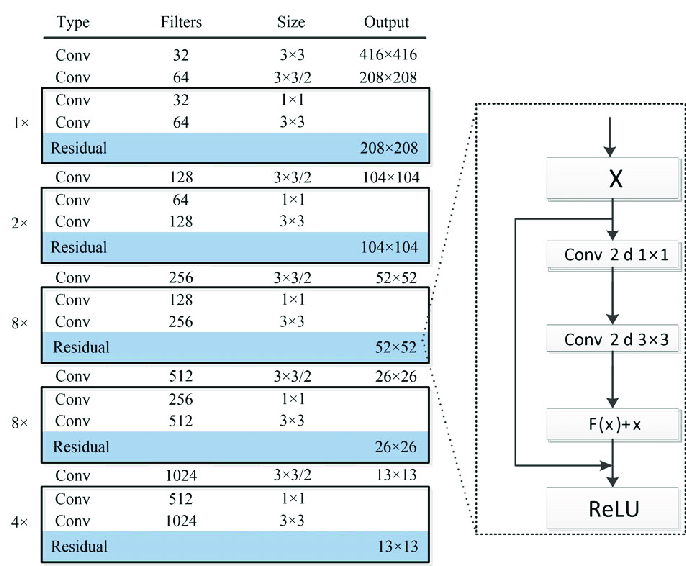

# CPU Implementation: Darknet53

## Test input

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(256, 256, 3)


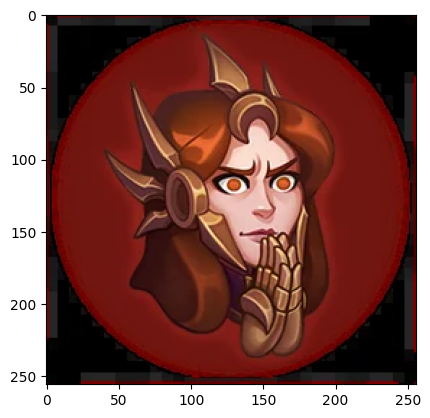

In [122]:
# image
from google.colab import drive
drive.mount('/content/drive')
image_path = '/content/drive/MyDrive/leona_icon.jpg'
import cv2
from matplotlib import pyplot as plt
import numpy as np
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = image.astype(np.uint8)
print(image.shape)
plt.imshow(image)

## Convolution layer

The convolution layer in a CNN shall include 3 steps:
1. Convolution with a 2D kernel.
2. Batch normalization.
3. Leaky ReLU.

In [123]:
kernel2d = np.array([[1, 1, 1],
                     [1, 1, 1],
                     [1, 1, 1]\
                     ], dtype=np.uint8)
kernel_sum = np.sum(kernel2d) * image.shape[2]
stride = 1
padding = 1
dilation = 1

### Convolution

In [124]:
from numba import jit

@jit
def trunc(val, min, max):
  if val < min:
    return min
  elif val > max:
    return max
  return val

@jit
def conv2d_cpu(image, kernel, kernel_sum, output, dil=1, stride=1, padding=0):
  for y in range(output.shape[1]):
    for x in range(output.shape[0]):
      sum = 0
      for y_t in range(kernel.shape[1]):
        for x_t in range(kernel.shape[0]):
          for i in range(3):
            input_x = trunc(x*stride+x_t*dil-padding, 0, image.shape[0]-1)
            input_y = trunc(y*stride+y_t*dil-padding, 0, image.shape[1]-1)
            sum += image[input_x, input_y, i] * kernel[x_t, y_t]
      output[x,y] = np.float32(sum / kernel_sum)
  return output

#### GPU implementation

Optimization idea: Since calculation for each output cell can be done separately, we can just divide that way.

In [125]:
# from numba import cuda

# @cuda.jit
# def trunc(val, min, max):
#   if val < min:
#     return min
#   elif val > max:
#     return max
#   return val

# @cuda.jit
# def conv2d_gpu_v1(image, kernel, kernel_sum, output, dil=1, str=1, padding=0):
#   idx = cuda.grid(2)
#   if idx[0] < output.shape[0] and idx[1] < output.shape[1]:
#     # calculate
#     sum = 0
#     for y_t in range(kernel.shape[1]):
#       for x_t in range(kernel.shape[0]):
#         for i in range(3):
#           input_x = trunc(idx[0]+x_t*dil-padding, 0, image.shape[0]-1)
#           input_y = trunc(idx[1]+y_t*dil-padding, 0, image.shape[1]-1)
#           sum += image[input_x, input_y, i] * kernel[x_t, y_t]

#     # write to GMEM
#     output[idx[0],idx[1]] = np.uint8(trunc(sum / kernel_sum, 0, 255))

In [126]:
# from numpy import testing
# from numba import cuda

# output_gpu = np.full(output_shape, fill_value = 0, dtype = np.uint8)
# d_image = cuda.to_device(image)
# d_kernel = cuda.to_device(kernel2d)
# d_output = cuda.to_device(output_gpu)

# blockSize = (16, 16)
# gridSize = (math.ceil(output_gpu.shape[0] / blockSize[0]), math.ceil(output_gpu.shape[1] / blockSize[1]))

In [127]:
# %timeit conv2d_gpu_v1[gridSize, blockSize](d_image, d_kernel, kernel_sum, d_output, dilation, stride, padding)
# print(np.array_equal(output_cpu, d_output.copy_to_host()))

### Batch normalization

Batch normalization here follows https://www.geeksforgeeks.org/deep-learning/what-is-batch-normalization-in-deep-learning/.

So here are the implementation steps:
1. Calculate variance and mean.
2. Pass through the function.

In [128]:
from numba import jit
import numpy as np

@jit
def mean_cpu(image2d):
  sum = 0
  for y in range(image2d.shape[1]):
    for x in range(image2d.shape[0]):
      sum += image2d[x,y]
  return sum / (image2d.shape[0] * image2d.shape[1])

@jit
def var_cpu(image2d):
  Mean = mean_cpu(image2d)
  L2sum = 0

  for y in range(image2d.shape[1]):
    for x in range(image2d.shape[0]):
      L2sum += (image2d[x,y] - Mean) ** 2
  return L2sum / (image2d.shape[0] * image2d.shape[1])

@jit
def bn_cpu(image3d, stab=1e-5):
  channels = image3d.shape[2]
  for c in range(channels):
    Mean = mean_cpu(image3d[c])
    Var = var_cpu(image3d[c])

    for y in range(image3d.shape[1]):
      for x in range(image3d.shape[0]):
        image3d[x,y] = (image3d[x,y] - Mean) / np.sqrt(Var + stab)

### Leaky ReLU

The formula simply is
$\text{LeakyReLU}(x) =
\begin{cases}
x & \text{if } x > 0 \\
\alpha x & \text{if } x \leq 0
\end{cases}
$, where $\alpha$ is small, can be 0.1 or 0.001 to still hold negative values but not remove them entirely.

In [129]:
from numba import jit

@jit
def leakyrelu_cpu(image3d, alpha=0.1):
  for c in range(image3d.shape[2]):
    for y in range(image3d.shape[1]):
      for x in range(image3d.shape[0]):
        if image3d[x,y,c] <= 0:
          image3d[x,y,c] *= alpha

### Result

In [167]:
from numba import jit
import math
from matplotlib import pyplot as plt

def conv_layer_cpu_show(image3d, kernel2d, kernel_sum, output, dil=1, stride=1, padding=0):
  plt.subplot(1, 4, 1)
  plt.axis('off')
  plt.imshow(image3d.astype(np.uint8))

  # convolution
  output_shape = (math.floor((image.shape[0] - (kernel2d.shape[0] - 1) * dil + 2*padding - 1) / stride) + 1,
                math.floor((image.shape[1] - (kernel2d.shape[1] - 1) * dil + 2*padding - 1) / stride) + 1,
                1)
  output = np.full(output_shape, fill_value = 0, dtype = np.float32)
  conv2d_cpu(image3d, kernel2d, kernel_sum, output, dil, stride, padding)

  plt.subplot(1, 4, 2)
  plt.axis('off')
  plt.imshow(output.astype(np.uint8), cmap='gray')

  # batch norm
  bn_cpu(output)

  plt.subplot(1, 4, 3)
  plt.axis('off')
  plt.imshow(output.astype(np.uint8), cmap='gray')

  # leaky ReLU
  leakyrelu_cpu(output)

  plt.subplot(1, 4, 4)
  plt.axis('off')
  plt.imshow(output.astype(np.uint8), cmap='gray')

  plt.figure(figsize=(15, 10))
  plt.show()

@jit
def conv_layer_cpu(image3d, kernel2d, kernel_sum, output, dil=1, stride=1, padding=0):
  # convolution
  output_shape = (math.floor((image.shape[0] - (kernel2d.shape[0] - 1) * dil + 2*padding - 1) / stride) + 1,
                math.floor((image.shape[1] - (kernel2d.shape[1] - 1) * dil + 2*padding - 1) / stride) + 1,
                1)
  output = np.full(output_shape, fill_value = 0, dtype = np.float32)
  conv2d_cpu(image3d, kernel2d, kernel_sum, output, dil, stride, padding)

  # batch norm
  bn_cpu(output)

  # leaky ReLU
  leakyrelu_cpu(output)

(256, 256, 3)


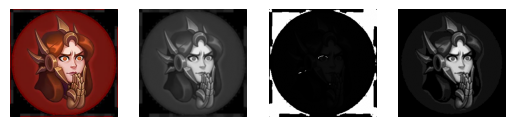

<Figure size 1500x1000 with 0 Axes>

(256, 256, 1)


In [168]:
print(image.shape)
output_shape = (math.floor((image.shape[0] - (kernel2d.shape[0] - 1) * dilation + 2*padding - 1) / stride) + 1,
                math.floor((image.shape[1] - (kernel2d.shape[1] - 1) * dilation + 2*padding - 1) / stride) + 1,
                1)
output_image3d = np.full(output_shape, fill_value = 0, dtype = np.float32)
conv_layer_cpu_show(image, kernel2d, kernel_sum, output_image3d, dilation, stride, padding)
print(output_image3d.shape)

## Residual block

A residual block consists of:
1. 2 convolution layers as the skip connection function $F$.
2. Residual connection of $F(x) + x$ as $x$ is the input image.
3. A final ReLU or LeakyReLU.

Since a residual block also includes convolution layers, and for presentation as well as future developments, it's time we implemented some OOP architecture.

# Implementation: CSP-enhanced Darknet53